# AlexNet — Krizhevsky et al. (2012), explained

Paper: *ImageNet Classification with Deep Convolutional Neural Networks*.

Goal of this notebook: **understand the architecture**, not to build a framework.
Anything PyTorch already provides (`nn.Conv2d`, `nn.MaxPool2d`, `nn.LocalResponseNorm`,
`CrossEntropyLoss`, `SGD`, `DataLoader`) is used as-is.

Here the paper's ImageNet task is swapped for **individual tiger identification** on the
[ATRW](https://cvwc2019.github.io/challenge.html) re-ID dataset: given a photo of a tiger, name
*which* of 107 known tigers it is.

**Layout**
1. Load the data
2. Helper functions, and why each one exists
3. The architecture — every layer, and the training step line by line
4. Train
5. Predict and validate
6. Glossary

**What the paper specifies** (kept): 5 convolutional layers, ReLU non-linearity,
overlapping max-pooling, local response normalization, and 3 fully connected layers.

**Where this adapts** (two places, on purpose):
- Paper's output is 1000 ImageNet classes. Here: output is **107 tiger identities**.
- Paper trained with aggressive random crops/flips on very large data. Here we keep a
  simpler resize-and-normalize pipeline because ATRW is much smaller.

# Section 1 — Loading the data

**ATRW (Amur Tiger Re-identification in the Wild), reid split**: photos of Amur tigers cropped
around the animal, each tagged with the identity of the tiger in it.

```
benchmarks/atrw_dataset_reid_tiger/
├── atrw_anno_reid_train/reid_list_train.csv   id, filename  (labelled)
├── atrw_reid_train/train/*.jpg                labelled + extra unlabelled crops
├── atrw_anno_reid_test/reid_list_test.csv     filename only (no id — used for the
│                                               official retrieval leaderboard, not
│                                               classification, so it's no use here)
└── atrw_reid_test/test/*.jpg
```

Two details this notebook works around:
- The train **folder** has 3,392 images but the train **CSV** only labels 1,887 of them (the
  rest are unlabelled crops used elsewhere in ATRW, e.g. pose estimation). We only use the
  1,887 labelled rows.
- The official test CSV has no identity labels. So "test" here means a held-out **validation
  split carved out of the labelled training rows** (stratified by tiger id), not the
  `atrw_reid_test` folder — there is no ground truth to score against there.

Two things happen to every image before it reaches the network:
- **Resize to 227×227.** AlexNet uses large RGB inputs (paper pipeline starts from resized
  256-side images and crops for training); here we keep a fixed-size input for clarity.
- **Normalise.** Pixel values are normalised channel-wise so optimisation is stable and faster.

In [1]:
import csv
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)

DATA_ROOT = Path("benchmarks/atrw_dataset_reid_tiger")
TRAIN_IMG_DIR = DATA_ROOT / "atrw_reid_train" / "train"
TRAIN_CSV = DATA_ROOT / "atrw_anno_reid_train" / "reid_list_train.csv"

print("torch", torch.__version__, "| device:", DEVICE)

torch 2.12.1+cu126 | device: cuda


In [2]:
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((227, 227)),            # fixed AlexNet-style input size
    transforms.ToTensor(),                     # PIL -> (3,227,227) float in 0..1
    transforms.Normalize(NORM_MEAN, NORM_STD),
])


def read_labels(csv_path):
    """CSV rows are 'id,filename' -> [(filename, id), ...]."""
    rows = []
    with open(csv_path, newline="") as f:
        for tiger_id, filename in csv.reader(f):
            rows.append((filename, int(tiger_id)))
    return rows


class TigerReIDDataset(Dataset):
    """One row = one photo of one tiger. Loads and transforms lazily, like any real dataset
    (unlike MNIST, these images don't fit comfortably as one big in-memory tensor)."""

    def __init__(self, samples, img_dir, class_to_idx, transform):
        self.samples = samples                   # [(filename, tiger_id), ...]
        self.img_dir = img_dir
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        filename, tiger_id = self.samples[i]
        img = Image.open(self.img_dir / filename).convert("RGB")
        return self.transform(img), self.class_to_idx[tiger_id]


def stratified_split(rows, val_fraction=0.15, seed=0):
    """Hold out val_fraction of EACH tiger's photos, so every identity appears in both splits
    (a plain random split could leave a rare tiger with zero training photos)."""
    import random
    by_id = {}
    for filename, tiger_id in rows:
        by_id.setdefault(tiger_id, []).append(filename)

    rng = random.Random(seed)
    train_rows, val_rows = [], []
    for tiger_id, files in by_id.items():
        files = files[:]
        rng.shuffle(files)
        n_val = max(1, round(len(files) * val_fraction))
        for f in files[:n_val]:
            val_rows.append((f, tiger_id))
        for f in files[n_val:]:
            train_rows.append((f, tiger_id))
    return train_rows, val_rows


def load_data():
    rows = read_labels(TRAIN_CSV)                                # 1,887 labelled (filename, id) pairs
    tiger_ids = sorted({tiger_id for _, tiger_id in rows})        # 107 real tiger ids, e.g. 1, 10, 96...
    class_to_idx = {tid: i for i, tid in enumerate(tiger_ids)}    # -> 0..106, what CrossEntropyLoss wants

    train_rows, val_rows = stratified_split(rows, val_fraction=0.15)
    tr = TigerReIDDataset(train_rows, TRAIN_IMG_DIR, class_to_idx, transform)
    te = TigerReIDDataset(val_rows, TRAIN_IMG_DIR, class_to_idx, transform)
    return tr, te, len(tiger_ids)

In [3]:
train_ds, test_ds, N_CLASSES = load_data()

print(f"{N_CLASSES} tiger identities | train: {len(train_ds)}  val/'test': {len(test_ds)}")
x0, y0 = train_ds[0]
print("one sample:", tuple(x0.shape), "label", int(y0),
      "| pixel range", float(x0.min()), "to", float(x0.max()))

107 tiger identities | train: 1588  val/'test': 299
one sample: (3, 227, 227) label 93 | pixel range -1.0561692714691162 to 1.942832350730896


In [4]:
# DataLoader = PyTorch's batching + shuffling. No reason to write our own.
BATCH = 64
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

xb, yb = next(iter(train_loader))
print("one batch:", tuple(xb.shape), "labels", tuple(yb.shape))

one batch: (64, 3, 227, 227) labels (64,)


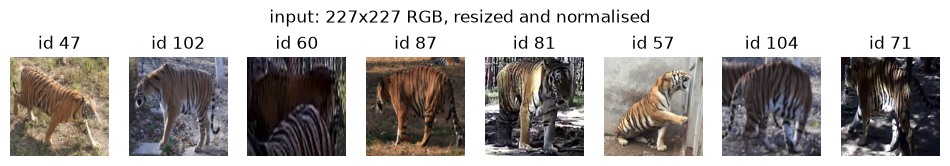

In [5]:
# Look at what we're feeding the network.
import matplotlib.pyplot as plt


def unnormalize(img):
    """(3,H,W) normalized tensor -> (H,W,3) array in 0..1, for display only."""
    mean = torch.tensor(NORM_MEAN).view(3, 1, 1)
    std = torch.tensor(NORM_STD).view(3, 1, 1)
    return (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img, lab in zip(axes, xb, yb):
    ax.imshow(unnormalize(img)); ax.set_title(f"id {int(lab)}"); ax.axis("off")
plt.suptitle("input: 227x227 RGB, resized and normalised")
plt.show()

# Section 2 — Helper functions, and why each exists

Four small helpers. Each answers one question you will ask while iterating.

In [6]:
def count_params(model):
    """WHY: capacity. AlexNet's original design is large (~60M parameters), and capacity
    directly affects both fit and overfitting risk on small datasets like ATRW."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def accuracy(model, loader):
    """WHY: the number you actually care about. Training loss can fall while accuracy
    stalls, so never judge a run by loss alone."""
    model.eval()                            # eval mode: turns off dropout/BN updates
    correct = total = 0
    for x, y in loader:
        pred = model(x.to(DEVICE)).argmax(1).cpu()   # argmax over the class scores
        correct += (pred == y).sum().item()
        total += len(y)
    return 100.0 * correct / total


@torch.no_grad()
def show_shapes(model, size=227, channels=3):
    """WHY: shape bugs are the most common bug in CNNs. Print what each layer does to the
    tensor so spatial downsampling is visible instead of assumed."""
    x = torch.zeros(1, channels, size, size, device=DEVICE)
    print(f"{'input':22} {tuple(x.shape)}")
    for name, layer in model.named_children():
        for sub_name, sub in layer.named_children():
            x = sub(x)
            print(f"{name}.{sub_name:<18} {tuple(x.shape)}")
    return x


def plot_history(history):
    """WHY: the shape of the curves tells you what to change next. Both losses falling
    together = keep training. Train falling, test flat or rising = overfitting."""
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot([h["train_loss"] for h in history], marker="o")
    ax[0].set_title("training loss"); ax[0].set_xlabel("epoch")
    ax[1].plot([h["train_acc"] for h in history], marker="o", label="train")
    ax[1].plot([h["test_acc"] for h in history], marker="o", label="test")
    ax[1].set_title("accuracy (%)"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()

# Section 3 — The architecture

## The shape of the idea

AlexNet stacks deep convolution blocks to learn hierarchical features:
- early layers detect edges/colour contrasts,
- middle layers capture texture and parts,
- later layers capture object-level patterns.

Compared with shallow CNNs, AlexNet's depth and width dramatically increase representational
power. The cost is a much larger parameter count, which is why regularisation (dropout) and
careful optimisation matter.

## The layers

| Layer | What it is | In → Out | Why |
|---|---|---|---|
| conv1 | 96 filters, 11×11, stride 4 | 3×227×227 → 96×55×55 | large first receptive field, fast downsampling |
| relu1 + lrn1 | ReLU then local response norm | 96×55×55 → 96×55×55 | nonlinearity + lateral competition |
| pool1 | max-pool 3×3, stride 2 | 96×55×55 → 96×27×27 | translation tolerance + shrink map |
| conv2 | 256 filters, 5×5, pad 2, groups 2 | 96×27×27 → 256×27×27 | richer mid-level features |
| relu2 + lrn2 + pool2 | same style as block 1 | 256×27×27 → 256×13×13 | stabilise and reduce spatial size |
| conv3 | 384 filters, 3×3, pad 1 | 256×13×13 → 384×13×13 | deeper feature composition |
| conv4 | 384 filters, 3×3, pad 1, groups 2 | 384×13×13 → 384×13×13 | high-level pattern refinement |
| conv5 | 256 filters, 3×3, pad 1, groups 2 | 384×13×13 → 256×13×13 | final convolutional abstraction |
| pool5 | max-pool 3×3, stride 2 | 256×13×13 → 256×6×6 | compact feature tensor |
| fc6 | dense 4096 | 256×6×6 → 4096 | global representation |
| fc7 | dense 4096 | 4096 → 4096 | high-capacity classifier features |
| fc8 | dense 107 | 4096 → 107 | one score per tiger identity |

Only the final classifier size changes from the paper (1000 → 107 classes).

In [7]:
class AlexNet(nn.Module):
    """AlexNet architecture with original layer pattern, adapted to N_CLASSES outputs."""

    def __init__(self, n_classes=107):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2.0),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(96, 256, kernel_size=5, padding=2, groups=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2.0),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 384, kernel_size=3, padding=1, groups=2),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1, groups=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = AlexNet(n_classes=N_CLASSES).to(DEVICE)
print(model)
print("\ntrainable parameters:", count_params(model), "(AlexNet is intentionally high-capacity)")

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
    (1): ReLU(inplace=True)
    (2): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2.0)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), groups=2)
    (5): ReLU(inplace=True)
    (6): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2.0)
    (7): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=2)
    (11): ReLU(inplace=True)
    (12): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=2)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatte

In [8]:
# Watch the tensor shrink and deepen through the network.
show_shapes(model);

input                  (1, 3, 227, 227)
features.0                  (1, 96, 55, 55)
features.1                  (1, 96, 55, 55)
features.2                  (1, 96, 55, 55)
features.3                  (1, 96, 27, 27)
features.4                  (1, 256, 27, 27)
features.5                  (1, 256, 27, 27)
features.6                  (1, 256, 27, 27)
features.7                  (1, 256, 13, 13)
features.8                  (1, 384, 13, 13)
features.9                  (1, 384, 13, 13)
features.10                 (1, 384, 13, 13)
features.11                 (1, 384, 13, 13)
features.12                 (1, 256, 13, 13)
features.13                 (1, 256, 13, 13)
features.14                 (1, 256, 6, 6)
classifier.0                  (1, 9216)
classifier.1                  (1, 9216)
classifier.2                  (1, 4096)
classifier.3                  (1, 4096)
classifier.4                  (1, 4096)
classifier.5                  (1, 4096)
classifier.6                  (1, 4096)
classifier.

## What one training step actually does

Five lines, run once per batch. This is the whole of "learning".

```python
scores = model(x)                 # 1. FORWARD
loss   = criterion(scores, y)     # 2. MEASURE THE ERROR
optimizer.zero_grad()             # 3. CLEAR OLD GRADIENTS
loss.backward()                   # 4. BACKWARD  (back-propagation)
optimizer.step()                  # 5. UPDATE THE WEIGHTS
```

**1. Forward.** The batch flows through conv blocks and fully connected layers and comes out as
107 logits per image. Higher logit means the model currently prefers that tiger identity.

**2. Loss.** `CrossEntropyLoss` compares those logits against the true class and returns one
number: how wrong we were.

**3. Zero the gradients.** PyTorch accumulates gradients into `.grad` by default. Without this
line, current and previous batch gradients would mix.

**4. Backward — back-propagation.** The chain rule runs from loss to every weight and stores
sensitivity in each parameter's `.grad` tensor.

**5. Update.** The optimiser moves each weight in the direction that reduces the loss.

Repeat over the whole dataset = one **epoch**.

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

x, y = next(iter(train_loader))
x, y = x.to(DEVICE), y.to(DEVICE)

# Pick one conv1 kernel weight and watch it change.
w = model.features[0].weight            # conv1 kernels, shape (96,3,11,11)
before = w[0, 0, 0, 0].item()
print("gradient before backward():", w.grad)          # None -- nothing computed yet

scores = model(x)                                     # 1. FORWARD
print("scores for one image (first 10 of", N_CLASSES, "):",
      scores[0, :10].detach().cpu().numpy().round(3))

loss = criterion(scores, y)                           # 2. HOW WRONG ARE WE
print("loss:", round(loss.item(), 4))

optimizer.zero_grad()                                 # 3. CLEAR
loss.backward()                                       # 4. BACKWARD -> fills .grad
print("gradient after backward():", round(w.grad[0, 0, 0, 0].item(), 6))

optimizer.step()                                      # 5. UPDATE
print(f"weight: {before:.6f} -> {w[0,0,0,0].item():.6f}  (moved against the gradient)")

gradient before backward(): None
scores for one image (first 10 of 107 ): [-0.02  -0.022  0.01   0.004  0.002 -0.008  0.003  0.013  0.005 -0.019]
loss: 4.6749
gradient after backward(): -2.8e-05
weight: -0.020215 -> -0.020215  (moved against the gradient)


# Section 4 — Training

Same five lines, now in a loop over epochs. `model.train()` / `model.eval()` are essential here
because AlexNet uses dropout in the classifier.

In [10]:
def fit(model, train_loader, test_loader, epochs=10, lr=0.05):
    """Train the model. Returns a history list you can plot."""
    import csv, time
    from pathlib import Path

    log_path = Path("runs") / "n2_AlexNet" / "history.csv"
    log_path.parent.mkdir(parents=True, exist_ok=True)

    def log_epoch_csv(rec):
        """Append one epoch's metrics as a CSV row -- survives a KeyboardInterrupt mid-training."""
        write_header = not log_path.exists()
        with open(log_path, "a", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=list(rec.keys()))
            if write_header:
                writer.writeheader()
            writer.writerow(rec)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    history = []

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        model.train()                                  # training mode
        running_loss, correct, seen = 0.0, 0, 0

        for x, y in train_loader:                      # one batch at a time
            x, y = x.to(DEVICE), y.to(DEVICE)

            scores = model(x)                          # 1. forward
            loss = criterion(scores, y)                # 2. error

            optimizer.zero_grad()                      # 3. clear old gradients
            loss.backward()                            # 4. back-propagate
            optimizer.step()                           # 5. update the weights

            running_loss += loss.item() * len(y)       # bookkeeping only
            correct += (scores.argmax(1) == y).sum().item()
            seen += len(y)

        test_acc = accuracy(model, test_loader)
        rec = {"epoch": epoch,
               "train_loss": running_loss / seen,
               "train_acc": 100.0 * correct / seen,
               "test_acc": test_acc,
               "error_rate": round(100.0 - test_acc, 4),
               "epoch_time_sec": round(time.time() - epoch_start, 2)}
        history.append(rec)
        log_epoch_csv(rec)
        print(f"epoch {epoch:2d}  loss {rec['train_loss']:.4f}  "
              f"train {rec['train_acc']:.2f}%  test {rec['test_acc']:.2f}%  "
              f"({rec['epoch_time_sec']:.1f}s)")

    return history

In [11]:
model = AlexNet(n_classes=N_CLASSES).to(DEVICE)     # fresh model
history = fit(model, train_loader, test_loader, epochs=30, lr=0.01)

epoch  1  loss 4.6678  train 4.35%  test 5.02%  (9.6s)
epoch  2  loss 4.6494  train 4.85%  test 5.02%  (9.1s)
epoch  3  loss 4.6244  train 5.16%  test 5.02%  (8.9s)
epoch  4  loss 4.4948  train 4.97%  test 5.35%  (8.8s)
epoch  5  loss 4.3281  train 5.04%  test 5.02%  (10.1s)
epoch  6  loss 4.1985  train 5.35%  test 7.02%  (8.7s)
epoch  7  loss 4.1043  train 5.60%  test 5.35%  (8.3s)
epoch  8  loss 4.0915  train 9.01%  test 8.36%  (8.3s)
epoch  9  loss 3.9147  train 9.13%  test 10.70%  (8.3s)
epoch 10  loss 4.0617  train 10.89%  test 10.03%  (8.3s)
epoch 11  loss 3.7314  train 12.47%  test 12.71%  (8.3s)
epoch 12  loss 3.5892  train 15.62%  test 14.05%  (8.3s)
epoch 13  loss 3.5672  train 16.06%  test 14.05%  (8.3s)
epoch 14  loss 3.4588  train 17.44%  test 11.37%  (8.2s)
epoch 15  loss 3.4210  train 18.45%  test 20.07%  (8.3s)
epoch 16  loss 3.1321  train 24.50%  test 21.74%  (8.2s)
epoch 17  loss 2.8744  train 26.32%  test 25.08%  (8.3s)
epoch 18  loss 2.6905  train 28.72%  test 28.43

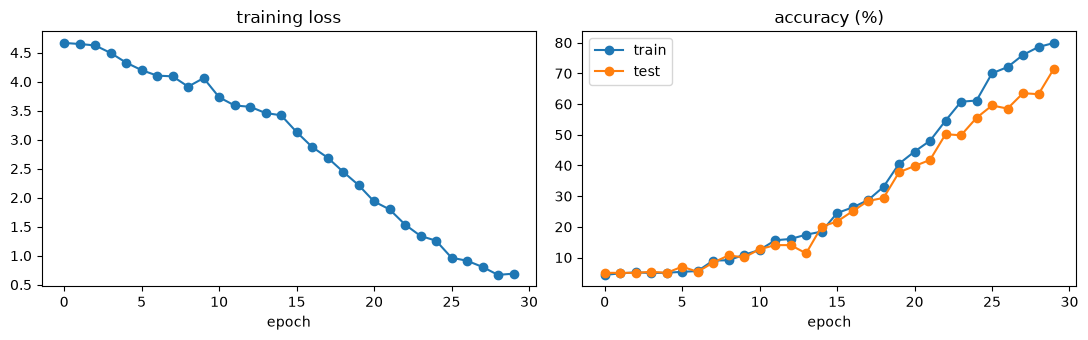

best held-out accuracy: 71.57190635451505 %
random guessing baseline: 0.93% (1 in 107)


In [12]:
plot_history(history)
print("best held-out accuracy:", max(h["test_acc"] for h in history), "%")
print(f"random guessing baseline: {100 / N_CLASSES:.2f}% (1 in {N_CLASSES})")

# Section 5 — Prediction and validation

Three checks, in increasing usefulness:
1. the raw error rate,
2. *which* identities it confuses (confusion matrix),
3. *what* it got wrong (look at the images).

Step 3 is the one that tells you what to fix.

In [13]:
@torch.no_grad()
def predict(model, x):
    """Returns (predicted class, confidence). Softmax turns raw scores into probabilities."""
    model.eval()
    probs = F.softmax(model(x.to(DEVICE)), dim=1)
    conf, pred = probs.max(1)
    return pred.cpu(), conf.cpu()


x, y = next(iter(test_loader))
pred, conf = predict(model, x[:8])
for i in range(8):
    mark = "ok " if pred[i] == y[i] else "XX "
    print(f"{mark} true tiger#{int(y[i])}  predicted tiger#{int(pred[i])}  confidence {conf[i]:.1%}")

ok  true tiger#93  predicted tiger#93  confidence 99.7%
ok  true tiger#93  predicted tiger#93  confidence 99.1%
ok  true tiger#93  predicted tiger#93  confidence 99.8%
XX  true tiger#97  predicted tiger#66  confidence 32.6%
ok  true tiger#97  predicted tiger#97  confidence 48.9%
XX  true tiger#97  predicted tiger#99  confidence 23.5%
ok  true tiger#62  predicted tiger#62  confidence 87.2%
ok  true tiger#62  predicted tiger#62  confidence 100.0%


held-out accuracy 71.57%   error rate 28.43%   misclassified 85


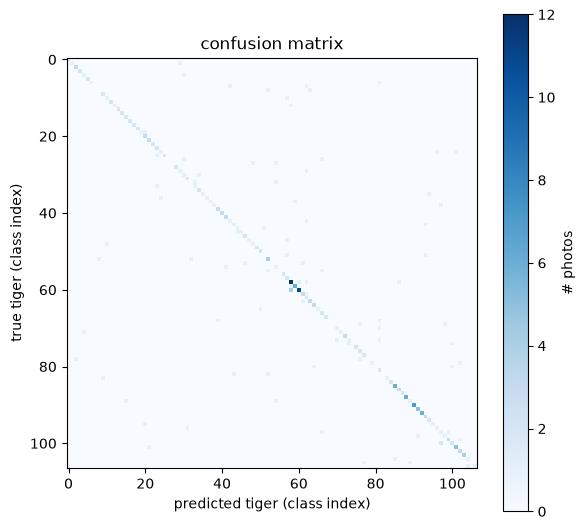

In [14]:
# Full held-out set: accuracy + confusion matrix.
@torch.no_grad()
def evaluate(model, loader, n_classes):
    model.eval()
    cm = torch.zeros(n_classes, n_classes, dtype=torch.long)   # rows = true, cols = predicted
    wrong_x, wrong_true, wrong_pred = [], [], []
    for x, y in loader:
        p = model(x.to(DEVICE)).argmax(1).cpu()
        for t, q in zip(y, p):
            cm[t, q] += 1
        bad = p != y
        if bad.any():
            wrong_x.append(x[bad]); wrong_true.append(y[bad]); wrong_pred.append(p[bad])
    acc = 100.0 * cm.diag().sum().item() / cm.sum().item()
    if wrong_x:
        wrong = (torch.cat(wrong_x), torch.cat(wrong_true), torch.cat(wrong_pred))
    else:
        wrong = (torch.empty(0), torch.empty(0), torch.empty(0))
    return acc, cm, wrong


acc, cm, wrong = evaluate(model, test_loader, N_CLASSES)
print(f"held-out accuracy {acc:.2f}%   error rate {100 - acc:.2f}%   misclassified {len(wrong[0])}")

# 107x107 is too big for per-cell numbers or tick labels, so just show the heatmap: a strong
# diagonal means the network tells tigers apart; scattered off-diagonal mass is the confusion.
fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xlabel("predicted tiger (class index)"); ax.set_ylabel("true tiger (class index)")
ax.set_title("confusion matrix")
plt.colorbar(im, ax=ax, label="# photos")
plt.tight_layout(); plt.show()

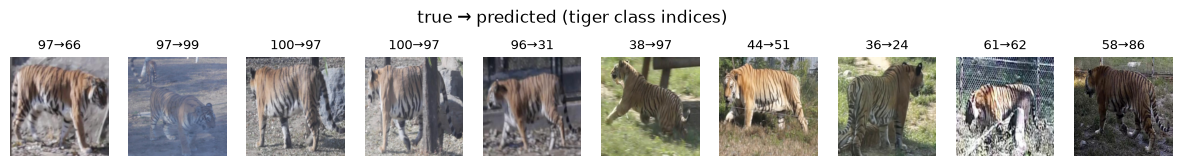

In [15]:
# Look at the mistakes. The paper does the same for MNIST (its Figure 8 shows all 82 errors);
# for tigers, expect confusions between individuals with similar stripe patterns or poses.
n = min(10, len(wrong[0]))
if n:
    fig, axes = plt.subplots(1, n, figsize=(1.5 * n, 2))
    for ax, img, t, p in zip(axes, wrong[0][:n], wrong[1][:n], wrong[2][:n]):
        ax.imshow(unnormalize(img)); ax.set_title(f"{int(t)}→{int(p)}", fontsize=9)
        ax.axis("off")
    plt.suptitle("true → predicted (tiger class indices)"); plt.show()
else:
    print("no mistakes on this run")

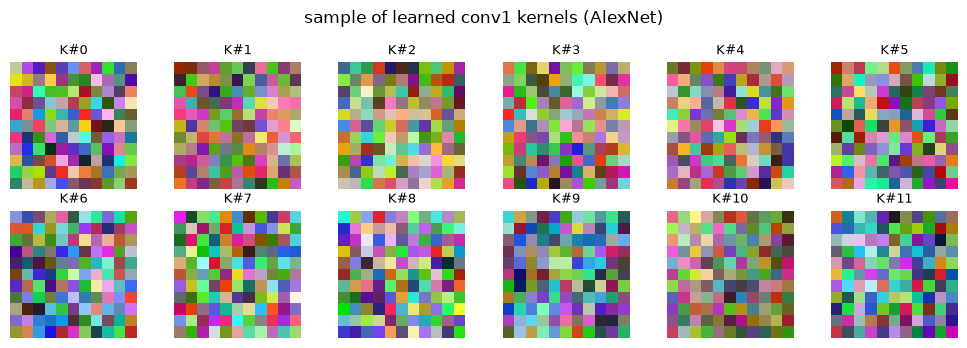

In [16]:
# What did conv1 actually learn? Each 11x11x3 tile is one kernel: an RGB colour/edge detector.
# Min-max normalised per kernel for display, since raw weights aren't in 0..1.
k = model.features[0].weight.detach().cpu()          # (96, 3, 11, 11)
fig, axes = plt.subplots(2, 6, figsize=(10, 3.5))
for i, ax in enumerate(axes.ravel()):
    tile = k[i].permute(1, 2, 0)                      # (11,11,3)
    tile = (tile - tile.min()) / (tile.max() - tile.min() + 1e-8)
    ax.imshow(tile); ax.set_title(f"K#{i}", fontsize=9); ax.axis("off")
plt.suptitle("sample of learned conv1 kernels (AlexNet)")
plt.tight_layout(); plt.show()

# Section 6 — Glossary

**Tensor** — an n-dimensional array. An image batch is a 4-D tensor `(batch, channels, height, width)`.

**Channel / feature map** — one 2-D slice of a layer's output. A conv layer outputs many feature maps.

**Kernel / filter** — the small grid of weights slid over the input. What the conv layer learns.

**Convolution** — sliding a kernel across the image, computing weighted sums at each position.

**Weight sharing** — the same kernel is reused at all positions, which keeps parameters manageable.

**Stride** — how far the kernel moves each step. Larger stride downsamples faster.

**Padding** — extra border pixels used to control output size and edge behavior.

**Pooling** — shrinking feature maps (here max pooling), which adds translation tolerance.

**Activation** — non-linearity after linear layers. AlexNet uses ReLU.

**Local response normalization (LRN)** — cross-channel competition used in original AlexNet blocks.

**Dropout** — randomly zeroes features during training to reduce overfitting.

**Fully connected (dense) layer** — every input connects to every output; parameter-heavy classifier layers.

**Logits** — raw class scores before softmax.

**Softmax** — turns logits into probabilities summing to 1.

**Loss function** — one scalar that measures prediction error. Cross-entropy is used here.

**Gradient** — derivative of loss w.r.t. parameter; direction and magnitude for updates.

**Back-propagation** — chain rule through the network to compute all gradients.

**Optimiser** — update rule that uses gradients to change parameters. Here: SGD with momentum.

**Learning rate** — update step size.

**Epoch** — one full pass over training data. **Batch** — subset processed before one update.

**Parameter** — learnable weight or bias. **Hyperparameter** — user-set value (lr, batch size, epochs).

**Training / validation split** — data used to fit vs. data used for held-out performance checks.

**Overfitting** — high training performance but weak held-out performance.

**Confusion matrix** — table of true vs. predicted classes. Off-diagonal mass = mistakes.

**`model.train()` / `model.eval()`** — switches training/inference behavior for layers like dropout.

**`zero_grad()`** — clears accumulated gradients before backpropagating the next batch.

**`torch.no_grad()`** — disables gradient tracking during evaluation; faster and lighter.

## Next steps

Change one thing, re-run `fit`, compare the held-out accuracy:

| Try | What it tells you |
|---|---|
| add `transforms.RandomHorizontalFlip()` | whether simple augmentation improves generalisation |
| add `transforms.RandomResizedCrop(227, scale=(0.8, 1.0))` | whether crop diversity helps identity robustness |
| lower LR after plateaus (e.g. `StepLR`) | whether optimisation, not architecture, is the bottleneck |
| reduce FC size (4096 -> 2048) | whether model is over-capacity for ATRW scale |
| freeze `features` for first few epochs | whether classifier-only warmup stabilises training |
| switch to Adam (`lr=1e-4`) | optimiser sensitivity on this dataset |

Change **one** at a time, and write down the number each time. That's how you learn which part
of the setup is actually carrying the result.

## Save results

Persist the trained model and validation metrics to `runs/<name>/`, so this run survives a kernel restart and can be compared against the other notebooks later.


In [17]:
# Save the trained model + validation results into runs/n2_AlexNet/, so this run isn't lost.
import json
from pathlib import Path

RUN_DIR = Path("runs") / "n2_AlexNet"
RUN_DIR.mkdir(parents=True, exist_ok=True)

torch.save({"model_state": model.state_dict(), "history": history}, RUN_DIR / "model.pt")

with open(RUN_DIR / "metrics.json", "w") as f:
    json.dump({
        "held_out_accuracy": acc,
        "best_test_acc_during_training": max(h["test_acc"] for h in history) if history else None,
        "misclassified": len(wrong[0]),
        "history": history,
    }, f, indent=2)

print("saved model + metrics to", RUN_DIR.resolve())


saved model + metrics to C:\Users\eeuma\Desktop\PhD Research Codes\5_systematically_move_to_best_architecture\runs\n2_AlexNet
